In [25]:
import yfinance as yf

gold = yf.download("GC=F", start="2010-01-01")
gold.head()


/var/folders/7x/1c_g2v5s46gd3rpq1b_zrd1r0000gn/T/ipykernel_70646/1105408922.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold = yf.download("GC=F", start="2010-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,
2010-01-04,1117.699951,1122.300049,1097.099976,1117.699951,184
2010-01-05,1118.099976,1126.500000,1115.000000,1118.099976,53
2010-01-06,1135.900024,1139.199951,1120.699951,1135.900024,363
2010-01-07,1133.099976,1133.099976,1129.199951,1133.099976,56
2010-01-08,1138.199951,1138.199951,1122.699951,1138.199951,54


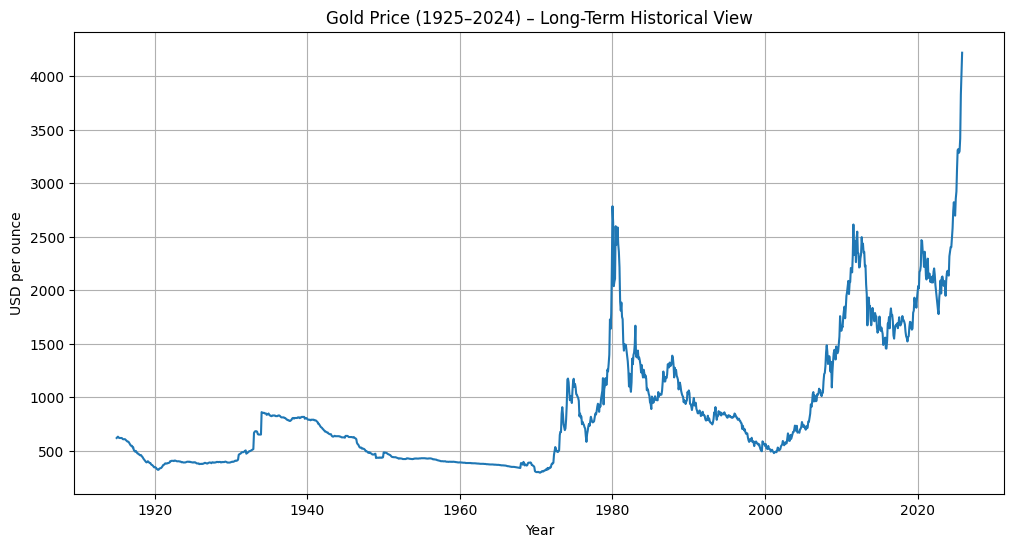

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("/Users/huangkang/Downloads/chart_20260107T071147.csv")

# Clean & preprocess
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

# Drop invalid rows & sort
df = df.dropna(subset=["Date", "Value"]).sort_values("Date")

# Plot
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Value"])
plt.title("Gold Price (1925–2024) – Long-Term Historical View")
plt.xlabel("Year")
plt.ylabel("USD per ounce")
plt.grid(True)
plt.show()


In [27]:
df["Year"] = df["Date"].dt.year

# Years you want (from the image)
selected_years = [1995, 1997, 1999, 2001, 2004]

# Take yearly average price for those years
gold_selected = (
    df[df["Year"].isin(selected_years)]
    .groupby("Year")["Value"]
    .mean()
    .reset_index()
)

gold_selected

,Year,Value
0,1995,816.274167
1,1997,665.182500
2,1999,545.957500
3,2001,496.278333
4,2004,703.125833


In [28]:
selected_years = [2005, 2008, 2010, 2011, 2014]

# Take yearly average price for those years
gold_selected = (
    df[df["Year"].isin(selected_years)]
    .groupby("Year")["Value"]
    .mean()
    .reset_index()
)

gold_selected

,Year,Value
0,2005,744.855000
1,2008,1325.583333
2,2010,1828.964167
3,2011,2258.011667
4,2014,1719.985833


In [29]:
selected_years = [2015, 2018, 2020, 2022, 2024, 2030]

# Take yearly average price for those years
gold_selected = (
    df[df["Year"].isin(selected_years)]
    .groupby("Year")["Value"]
    .mean()
    .reset_index()
)

gold_selected

,Year,Value
0,2015,1575.655000
1,2018,1634.012500
2,2020,2234.524167
3,2022,1994.390000
4,2024,2483.181667


In [32]:

yearly_method = "avg"

if yearly_method == "avg":
    yearly = df.groupby("Year")["Value"].mean().reset_index()
elif yearly_method == "end":
    yearly = df.groupby("Year").tail(1)[["Year", "Value"]].reset_index(drop=True)
else:
    raise ValueError("yearly_method must be 'avg' or 'end'")

# 3) Các giai đoạn bạn muốn tổng kết
periods = [
    (1995, 2004),
    (2005, 2014),
    (2015, 2025),
]

# 4) Hàm lấy giá ở năm gần nhất trong data (phòng khi thiếu đúng năm)
def get_price_for_year(y: int) -> float:
    sub = yearly[yearly["Year"] == y]
    if not sub.empty:
        return float(sub["Value"].iloc[0])

    # nếu thiếu đúng năm, lấy năm gần nhất
    yearly_years = yearly["Year"].values
    nearest = yearly_years[(abs(yearly_years - y)).argmin()]
    return float(yearly.loc[yearly["Year"] == nearest, "Value"].iloc[0])

# 5) Build summary table
rows = []
for start_y, end_y in periods:
    start_price = get_price_for_year(start_y)
    end_price = get_price_for_year(end_y)
    increase = end_price - start_price
    multiple = end_price / start_price if start_price != 0 else float("nan")

    rows.append({
        "Period": f"{start_y}–{end_y}",
        "Start Price (USD/oz)": start_price,
        "End Price (USD/oz)": end_price,
        "Increase (USD/oz)": increase,
        "Multiple (x)": multiple
    })

# total row: từ period đầu -> period cuối
total_start = periods[0][0]
total_end = periods[-1][1]
total_start_price = get_price_for_year(total_start)
total_end_price = get_price_for_year(total_end)

rows.append({
    "Period": f"{total_start}–{total_end}",
    "Start Price (USD/oz)": total_start_price,
    "End Price (USD/oz)": total_end_price,
    "Increase (USD/oz)": total_end_price - total_start_price,
    "Multiple (x)": (total_end_price / total_start_price) if total_start_price != 0 else float("nan")
})

summary = pd.DataFrame(rows)

# 6) Format cho đẹp (tuỳ bạn)
summary["Start Price (USD/oz)"] = summary["Start Price (USD/oz)"].round(2)
summary["End Price (USD/oz)"] = summary["End Price (USD/oz)"].round(2)
summary["Increase (USD/oz)"] = summary["Increase (USD/oz)"].round(2)
summary["Multiple (x)"] = summary["Multiple (x)"].round(2)

summary


,Period,Start Price (USD/oz),End Price (USD/oz),Increase (USD/oz),Multiple (x)
0,1995–2004,816.27,703.13,-113.15,0.86
1,2005–2014,744.86,1719.99,975.13,2.31
2,2015–2025,1575.66,3416.98,1841.33,2.17
3,1995–2025,816.27,3416.98,2600.71,4.19


In [33]:

# Filter 2000–2025
df_25y = df[(df["Year"] >= 2000) & (df["Year"] <= 2025)].copy()

# Yearly features
yearly = (
    df_25y.groupby("Year")["Value"]
    .agg(
        Avg_Price="mean",        # Giá trung bình
        Start_Year="first",      # Giá đầu năm (giá đầu tiên trong năm)
        High="max",              # Giá cao
        Low="min",               # Giá thấp
        End_Year="last"          # Giá cuối năm (giá cuối cùng trong năm)
    )
    .reset_index()
)

# Thay đổi % (YoY theo giá cuối năm)
yearly["Change_%"] = yearly["End_Year"].pct_change() * 100

# Làm đẹp
yearly = yearly.rename(columns={
    "Year": "Năm",
    "Avg_Price": "Giá trung bình",
    "Start_Year": "Giá đầu năm",
    "High": "Giá cao",
    "Low": "Giá thấp",
    "End_Year": "Giá cuối năm",
    "Change_%": "Thay đổi %"
})

yearly


,Năm,Giá trung bình,Giá đầu năm,Giá cao,Giá thấp,Giá cuối năm,Thay đổi %
0,2000,520.916667,543.50,561.20,491.40,507.88,NaN
1,2001,496.278333,492.75,528.72,476.53,507.19,-0.135859
2,2002,563.632500,515.19,614.11,515.19,614.11,21.080857
3,2003,647.674167,660.64,733.80,590.09,733.80,19.489994
4,2004,703.125833,702.32,767.03,666.73,746.01,1.663941
5,2005,744.855000,720.31,844.89,695.09,844.89,13.254514
6,2006,983.023333,931.34,1046.79,907.77,1021.03,20.847684
7,2007,1100.995833,1034.02,1290.86,1008.84,1290.86,26.427235
8,2008,1325.583333,1418.46,1483.63,1090.27,1333.63,3.313295
9,2009,1484.049167,1409.97,1755.98,1351.27,1657.01,24.248105
